<a href="https://www.kaggle.com/code/batuhaneralpofficial/arrythmia-detection-from-ecg-data?scriptVersionId=302613755" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

plt.style.use("fivethirtyeight")

colors = ["Teal","Indigo","HotPink","DarkGoldenRod","Coral"]

Data is prepared as it has been provided by Bülent Esen's notebook https://www.kaggle.com/bulentesen/cardiac-arrythmia-naive-bayes-v2 who is the publisher of the dataset. No further data preparation besides the ones in cell 8 were not pursued since the data preparataion should be at it's best under the owner's own usage.

In [2]:
print(os.listdir('../input'))

['data_arrhythmia.csv']


Data is a .CSV file which contains all the possible instructions that can be obtained from ECG readings. However some of the columns have unreliable data (nulls and just vectors of singular values to be exact). So the owner of the dataset seems to drop these columns not applying any interpolation implementation. So, this notebook doesn't follow any interpolation measure either.

In [3]:
df = pd.read_csv('../input/data_arrhythmia.csv', delimiter=';')

In [4]:
df.head()

,age,sex,height,weight,qrs_duration,p-r_interval,q-t_interval,t_interval,p_interval,qrs,...,KY,KZ,LA,LB,LC,LD,LE,LF,LG,diagnosis
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0,-0.1,3.9,25.4,62.8,7


In [5]:
df.drop(["J","R'_wave","S'_wave", "AB", "AC", "AD","AE", "AF", "AG", "AL", "AN", "AO", "AP", "AR", "AS", "AT", "AZ", "AB'", "BC", "BD", "BE", "BG", "BH", "BP", "BR", "BS", "BT", "BU", 
          "CA", "CD", "CE", "Cf", "CG", "CH", "CI", "CM","CN","CP","CR","CS","CT","CU","CV","DE","DF","DG","DH","DI","DJ","DR","DS","DT","DU","DV","DY","EG",
          "EH", "EL", "ER", "ET", "EU", "EV", "EY", "EZ", "FA", "FE", "FF", "FH", "FI", "FJ", "FK", "FL", "FM", "FR", "FS", "FU", "FV", "FY", "FZ", "GA",
          "GB", "GG", "GH", "HD", "HE", "HO", "IA", "IB", "IK", "IL", "IY", "JI", "JS", "JT", "KF", "KO", "KP", "LB", "LC", "T", "P", "QRST", "heart_rate"], axis=1, inplace=True)

In [6]:
df.head()

,age,sex,height,weight,qrs_duration,p-r_interval,q-t_interval,t_interval,p_interval,qrs,...,KU,KV,KY,KZ,LA,LD,LE,LF,LG,diagnosis
0,75,0,190,80,91,193,371,174,121,-16,...,62.9,-0.3,0.0,9.0,-0.9,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,43.4,-0.5,0.0,8.5,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,48.2,0.9,0.0,9.5,-2.4,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,68.0,0.1,0.0,12.2,-2.2,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,48.9,-0.4,0.0,13.1,-3.6,-0.1,3.9,25.4,62.8,7


Further investigating the data have revealed there are some odd entries for the entries that are made presumably for babies which is handled manually. https://www.kaggle.com/mtavares51/binary-classification-on-arrhythmia-dataset

In [7]:
df['height'].value_counts().sort_index()

height
105     1
110     1
119     1
120     2
124     1
127     1
130     2
132     1
133     1
138     1
140     1
146     1
148     1
149     1
150     9
152     1
153     5
154     4
155    23
156    19
157    10
158     9
159     6
160    81
161     5
162    15
163    16
164     9
165    46
166     9
167     8
168    15
169     7
170    40
171     9
172    14
173     7
174     4
175    21
176    10
177     4
178     9
179     1
180     4
181     1
182     2
184     1
185     3
186     3
188     1
190     3
608     1
780     1
Name: count, dtype: int64

In [8]:
df.loc[df["height"] == 608, "height"] = 61
df.loc[df["height"] == 780, "height"] = 78
df['height'].value_counts().sort_index()

height
61      1
78      1
105     1
110     1
119     1
120     2
124     1
127     1
130     2
132     1
133     1
138     1
140     1
146     1
148     1
149     1
150     9
152     1
153     5
154     4
155    23
156    19
157    10
158     9
159     6
160    81
161     5
162    15
163    16
164     9
165    46
166     9
167     8
168    15
169     7
170    40
171     9
172    14
173     7
174     4
175    21
176    10
177     4
178     9
179     1
180     4
181     1
182     2
184     1
185     3
186     3
188     1
190     3
Name: count, dtype: int64

There are 16 classes as follows
<ol>
<li>Normal                     </li>
<li>Ischemic changes (Coronary Artery Disease</li>
<li>Old Anterior Myocardial Infarction     </li>
<li>Old Inferior Myocardial Infarction     </li>
<li>Sinus tachycardy                 </li>
<li>Sinus bradycardy                 </li>
<li>Ventricular Premature Contraction (PVC)</li>
<li>Supraventricular Premature Contraction </li>
<li>Left bundle branch block                 </li>
<li>Right bundle branch block             </li>
<li>1. degree AtrioVentricular block            </li>
<li>2. degree AV block             </li>
<li>3. degree AV block             </li>
<li>Left ventricule hypertrophy          </li>
<li>Atrial Fibrillation or Flutter         </li>
<li>Others                     </li>
</ol>

However only first one is a normal kind of arrythmia where the other classes can be superclassed as risky arrythmia cases. In this notebook, all cases are classified as either normal or risky. Risky being the positive (True) case and normal being the negative (False) case, diagnosis column is reworked as follows.

In [9]:
norm_risk_list = []
for diagnose in df.diagnosis:
    if diagnose == 1:
        norm_risk_list.append(True)
    else:
        norm_risk_list.append(False)
df["label"] = np.array(norm_risk_list)
df.drop(columns = ["diagnosis"],inplace = True)
df.label.value_counts()

label
True     245
False    207
Name: count, dtype: int64

X is formed by importing every data at first. All the dimensionality reduction will be applied afterwards. Y is the label column.

In [10]:
X = df.drop(columns = [df.columns[-1]])
y = df[df.columns[-1]]
print(X.shape)
print(y.shape)

(452, 176)
(452,)


A train test split have been implemented with 0.2 test_size value.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(361, 176)
(361,)
(91, 176)
(91,)


For every column, a MinMaxScaler have been implemented

In [12]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = X_train_scaled
X_test = X_test_scaled

All model names are inputted for demonstration use afterwards.

In [13]:
model_names = ["Logistic Regression",
               "K-Nearest Neighbors",
               "Decision Tree Classifier",
               "Random Forest Classifier",
               "Gaussian Naive Bayes"]

models = []
predictions = []
pred_probabilities = []

LogisticRegression have been trained.

In [14]:
log_model = LogisticRegression(random_state=0,solver = "saga")
models.append(log_model)
log_model.fit(X_train, y_train)
log_predprob = log_model.predict_proba(X_test)
pred_probabilities.append(log_predprob)
log_pred = log_model.predict(X_test)
predictions.append(log_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


KNeighborsClassifier model have been trained

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=80)
models.append(knn_model)
knn_model.fit(X_train, y_train)
knn_predprob = knn_model.predict_proba(X_test)
pred_probabilities.append(knn_predprob)
knn_pred = knn_model.predict(X_test)
predictions.append(knn_pred)

The cell below checks for a range of n_neighbors values and picking the best n_neighbors with the highest AUROC result. Commented out since it's implemented above manually however it's left here for demonstration purposes

In [16]:
#best_score = -np.inf
#best_n = np.inf
#for n in range(1,df.columns.shape[0]):
#    temp_model = KNeighborsClassifier(n_neighbors=n)
#    print(n,end=" ")
#    temp_model.fit(X_train, y_train)
#    temp_predprob = temp_model.predict_proba(X_test)
#    temp_score = roc_auc_score(y_test,temp_predprob[:, 1])
#    if temp_score > best_score:
#            best_score = temp_score
#            best_n = n
#print("Best performing number of n_neighbors is",best_n,"scoring",round(best_score * 100 , 2))



DecisionTreeClassifier model have been trained

In [17]:
tree_model = DecisionTreeClassifier(random_state=0,max_depth = 8,max_features="sqrt")
models.append(tree_model)
tree_model.fit(X_train, y_train)
tree_predprob = tree_model.predict_proba(X_test)
pred_probabilities.append(tree_predprob)
tree_pred = tree_model.predict(X_test)
predictions.append(tree_pred)

The cell below checks for a range of max_depth values and picking the best n_neighbors with the highest AUROC result. Commented out since it's implemented above manually however it's left here for demonstration purposes

In [18]:
#best_score = -np.inf
#best_n = np.inf
#for n in range(1,df.columns.shape[0]):
#    temp_tree_model = DecisionTreeClassifier(random_state=0,max_depth = n,max_features="sqrt")
#    print(n,end=" ")
#    temp_tree_model.fit(X_train, y_train)
#    temp_tree_predprob = temp_tree_model.predict_proba(X_test)
#    temp_score = roc_auc_score(y_test,temp_tree_predprob[:, 1])
#    if temp_score > best_score:
#            best_score = temp_score
#            best_n = n
#print("Best performing number of max_depth is",best_n,"scoring",round(best_score * 100 , 2))

RandomForestClassifier model have been trained

In [19]:
rndfor_model = RandomForestClassifier(max_depth=9, random_state=0,n_estimators = 100)
models.append(rndfor_model)
rndfor_model.fit(X_train, y_train)
rndfor_predprob = rndfor_model.predict_proba(X_test)
pred_probabilities.append(rndfor_predprob)
rndfor_pred = rndfor_model.predict(X_test)
predictions.append(rndfor_pred)

The cell below checks for a range of max_depth values and picking the best n_neighbors with the highest AUROC result. Commented out since it's implemented above manually however it's left here for demonstration purposes

In [20]:
#best_score = -np.inf
#best_n = np.inf
#for n in range(1,df.columns.shape[0]):
#    temp_tree_model = RandomForestClassifier(max_depth=n, random_state=0,n_estimators = 100)
#    print(n,end=" ")
#    temp_tree_model.fit(X_train, y_train)
#    temp_tree_predprob = temp_tree_model.predict_proba(X_test)
#    temp_score = roc_auc_score(y_test,temp_tree_predprob[:, 1])
#    if temp_score > best_score:
#            best_score = temp_score
#            best_n = n
#print("Best performing number of max_depth is",best_n,"scoring",round(best_score * 100 , 2))

GaussianNB model have been trained

In [21]:
nb_model = GaussianNB(var_smoothing = 0.00001)
models.append(nb_model)
nb_model.fit(X_train, y_train)
nb_predprob = nb_model.predict_proba(X_test)
pred_probabilities.append(nb_predprob)
nb_pred = nb_model.predict(X_test)
predictions.append(nb_pred)
nb_predprob.shape


(91, 2)

Just for demonstration accuracy scores have been demonstrated however ignored in fine-tuning to create a mor clinically applicable model favoring a varibale threshold rather than a 50 % fixed threshold.

In [22]:
for name,pred in zip(model_names,predictions):
    print(name,"Accuracy:",round(accuracy_score(y_test,pred) * 100 , 2),"%")

Logistic Regression Accuracy: 74.73 %
K-Nearest Neighbors Accuracy: 56.04 %
Decision Tree Classifier Accuracy: 73.63 %
Random Forest Classifier Accuracy: 74.73 %
Gaussian Naive Bayes Accuracy: 78.02 %


For each model AUROC scores are as below.

In [23]:
for name,pred in zip(model_names,pred_probabilities):
    print(name,"AUROC:",round(roc_auc_score(y_test,pred[:, 1]) * 100 , 2),"%")

Logistic Regression AUROC: 78.72 %
K-Nearest Neighbors AUROC: 75.61 %
Decision Tree Classifier AUROC: 77.87 %
Random Forest Classifier AUROC: 81.58 %
Gaussian Naive Bayes AUROC: 79.88 %


For each model, a ROC curve have been created using Scikit-Learn's own roc_curve function and stylized for demstrative purposes. Each plot has AUROC score in the title as well as an indicator of how many components in PCA have been chosen (in this case none chosen).

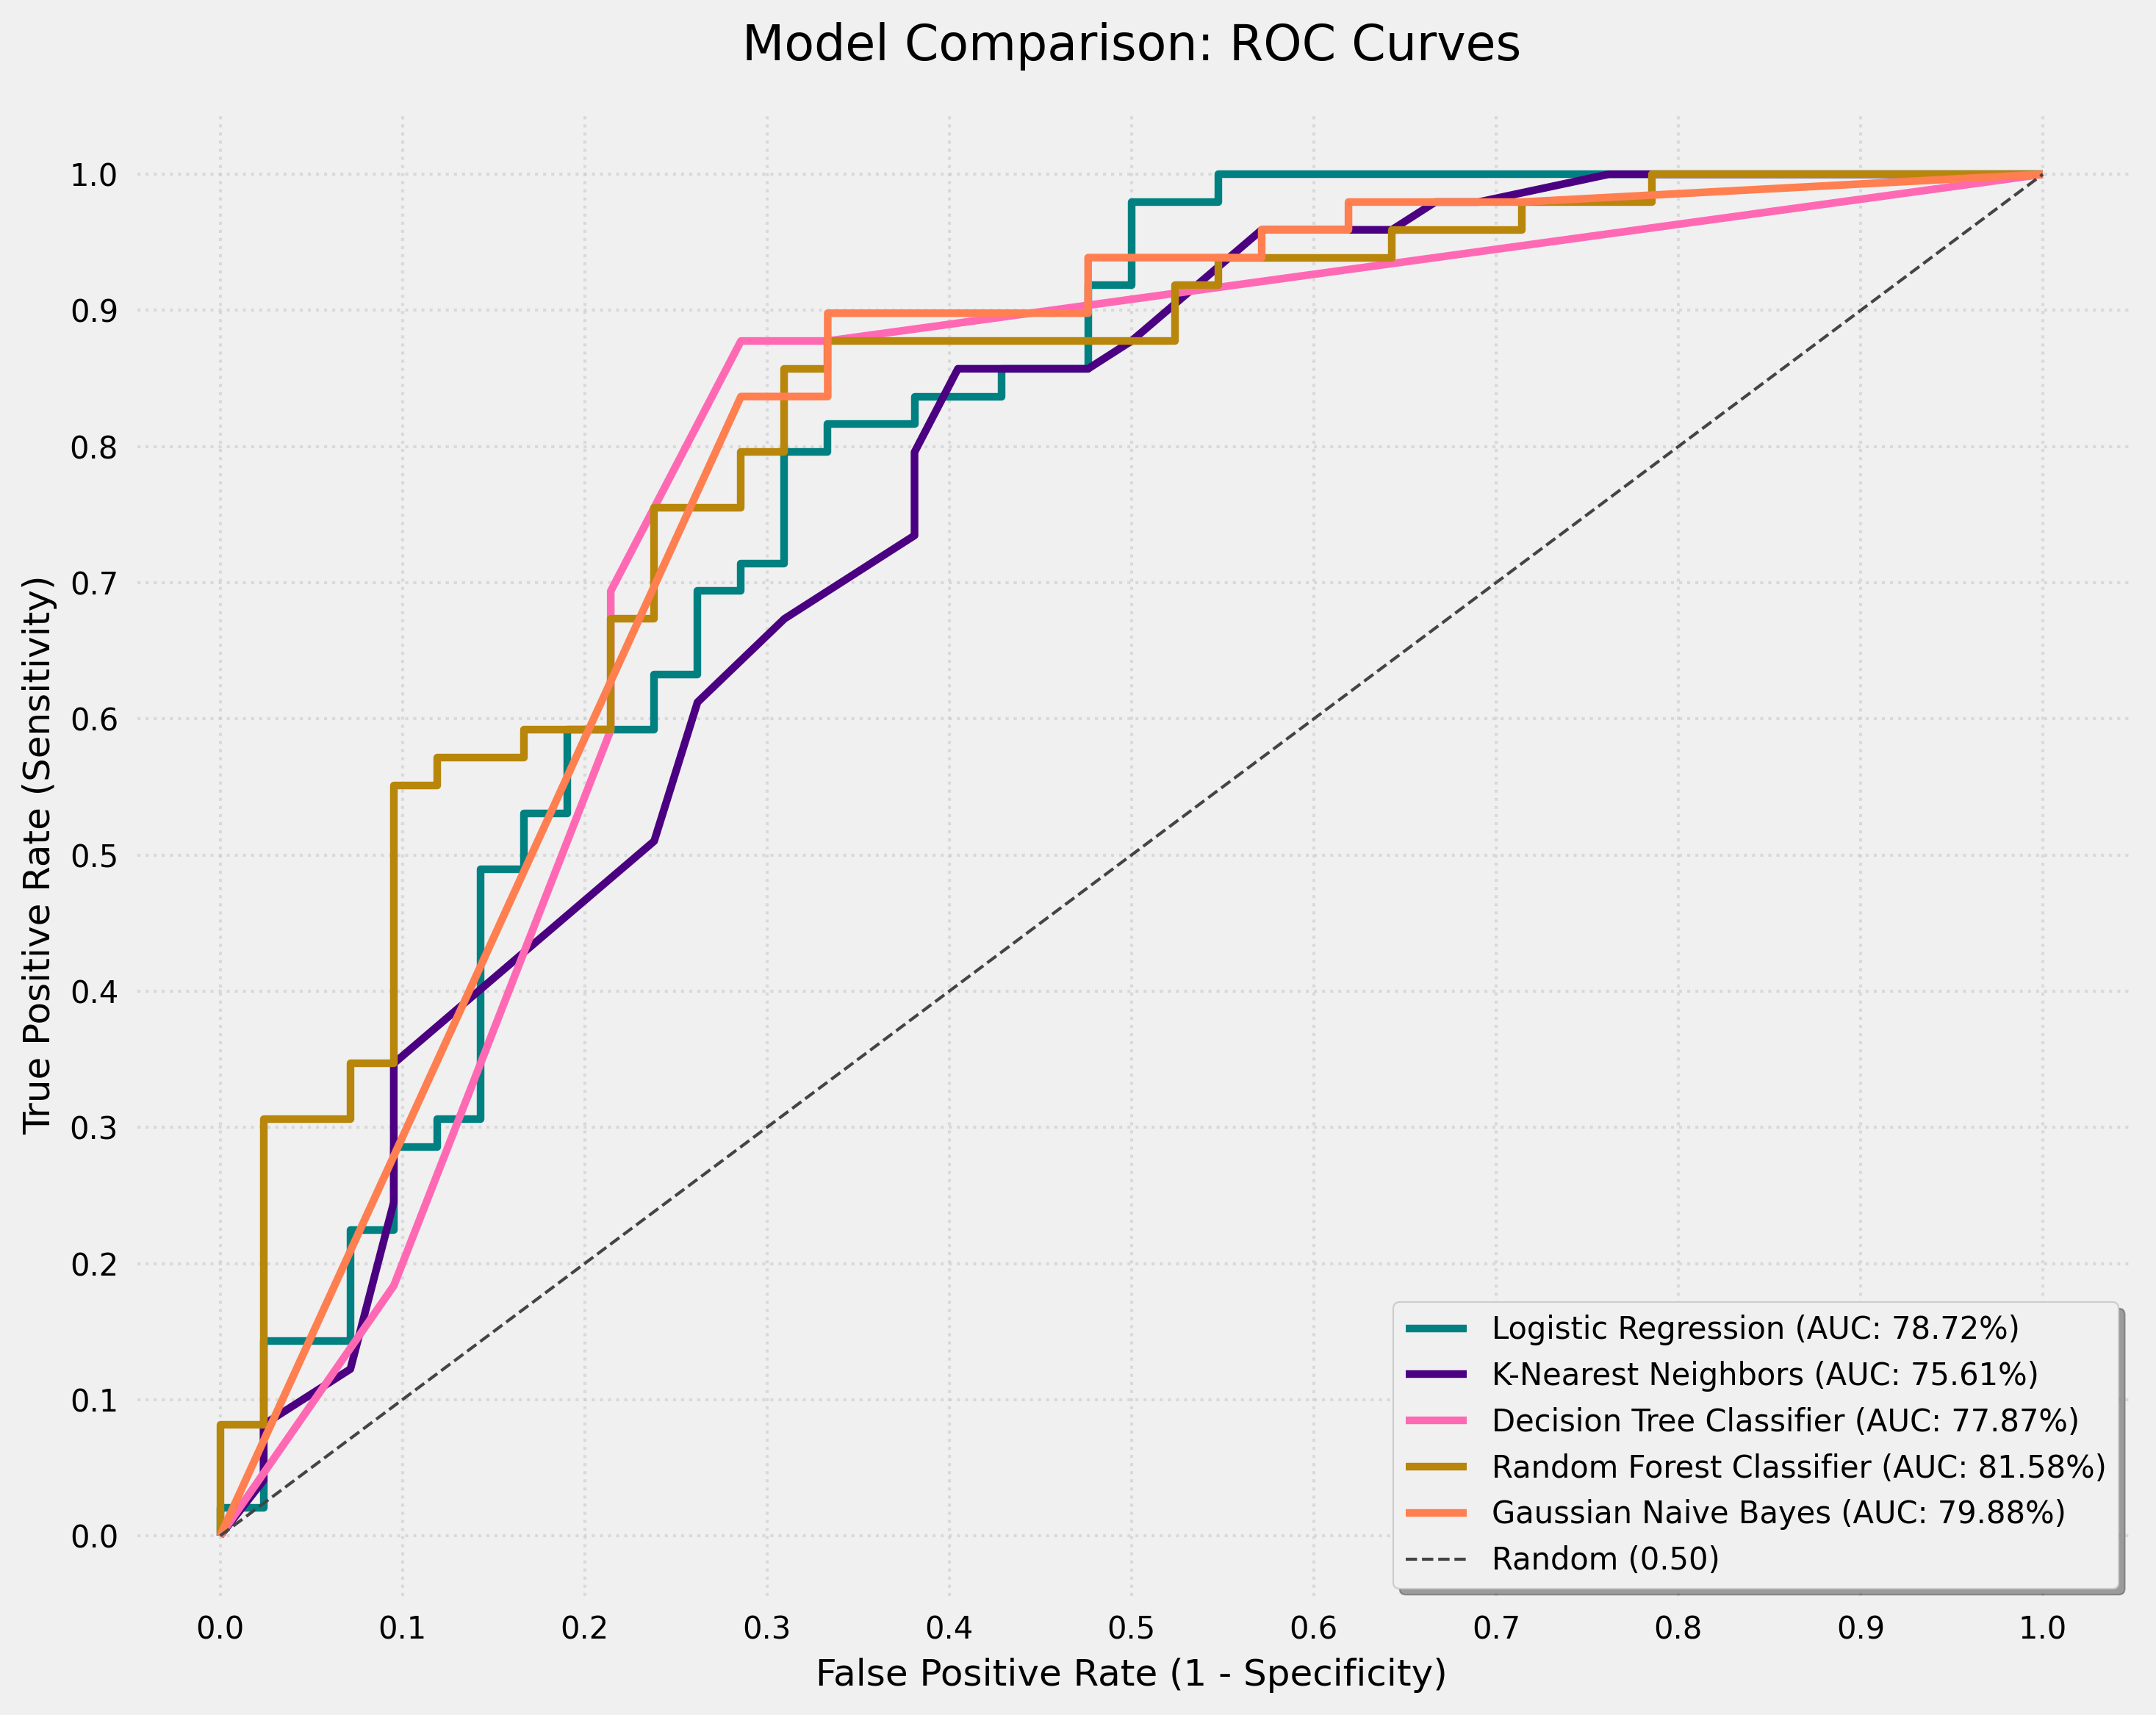

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Set a high DPI for crisp resolution
plt.figure(figsize=(10, 8), dpi=300) 

for i, pred in enumerate(pred_probabilities):
    fpr, tpr, _ = roc_curve(y_test, pred[:, 1], drop_intermediate=False)
    auc_score = roc_auc_score(y_test, pred[:, 1])
    
    label_text = f"{model_names[i]} (AUC: {auc_score:.2%})"
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, label=label_text) # Thicker lines help

plt.plot([0, 1], [0, 1], linestyle='--', color='#444444', lw=1, label="Random (0.50)")

# Formatting
plt.title("Model Comparison: ROC Curves", fontsize=16, pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)

# Professional grid and ticks
plt.xticks([x/10 for x in range(11)], fontsize=10)
plt.yticks([x/10 for x in range(11)], fontsize=10)
plt.grid(visible=True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)

# 2. Tight layout prevents label clipping
plt.tight_layout() 

plt.show()

For each model, the cell above finds the best performing number of components in PCA. In this way, each model has their own best performing dataset and using features as much as they need to further optimize AUROC score.

In [25]:
from sklearn.decomposition import PCA
best_scores = []
best_ns = []

# Calculating overall best
ob_model_name = ""
ob_model_score = -np.inf
ob_best_pred = []

for i, model in enumerate(models):
    best_score = -np.inf
    best_n = np.inf
    best_pred = []
    for n in range(1,df.columns.shape[0]):
        pca = PCA(n_components=n,random_state = 0)
        temp_X_train = pca.fit_transform(X_train)
        temp_X_test = pca.transform(X_test)
        model.fit(temp_X_train,y_train)
        temp_pred = model.predict_proba(temp_X_test)
        temp_score = roc_auc_score(y_test,temp_pred[:, 1])
        if temp_score > best_score:
            best_score = temp_score
            best_n = n
            best_pred = temp_pred
    print("Best performing number of components for",model_names[i],"is",best_n,"scoring",round(best_score * 100 , 2))
    if best_score > ob_model_score:
        ob_model_score = best_score
        ob_model_name = model_names[i]
        ob_best_pred = best_pred
    best_scores.append(best_score)
    best_ns.append(best_n)

Best performing number of components for Logistic Regression is 46 scoring 79.59
Best performing number of components for K-Nearest Neighbors is 25 scoring 78.96
Best performing number of components for Decision Tree Classifier is 10 scoring 75.39
Best performing number of components for Random Forest Classifier is 113 scoring 85.37
Best performing number of components for Gaussian Naive Bayes is 54 scoring 79.2


The cell below computes a common number of components which all models perform the best in average. Although this approach limits the performance of each model on their own, it demonstrates how much of the features is actually put into good use especially since the number of futures are less than half of the original number of features after this implementation.

Cell below computes predictions with probabilities using varying number of PCA components, computed above and stores them in an array.

In [26]:
pca_pred_probs = []
for i, model in enumerate(models):
    pca = PCA(n_components=best_ns[i],random_state = 0)
    temp_X_train = pca.fit_transform(X_train)
    temp_X_test = pca.transform(X_test)
    model.fit(temp_X_train,y_train)
    temp_pred = model.predict_proba(temp_X_test)
    pca_pred_probs.append(temp_pred)

For each model, a ROC curve have been created using Scikit-Learn's own roc_curve function and stylized for demstrative purposes. Each plot has AUROC score in the title as well as an indicator of how many components in PCA have been chosen.

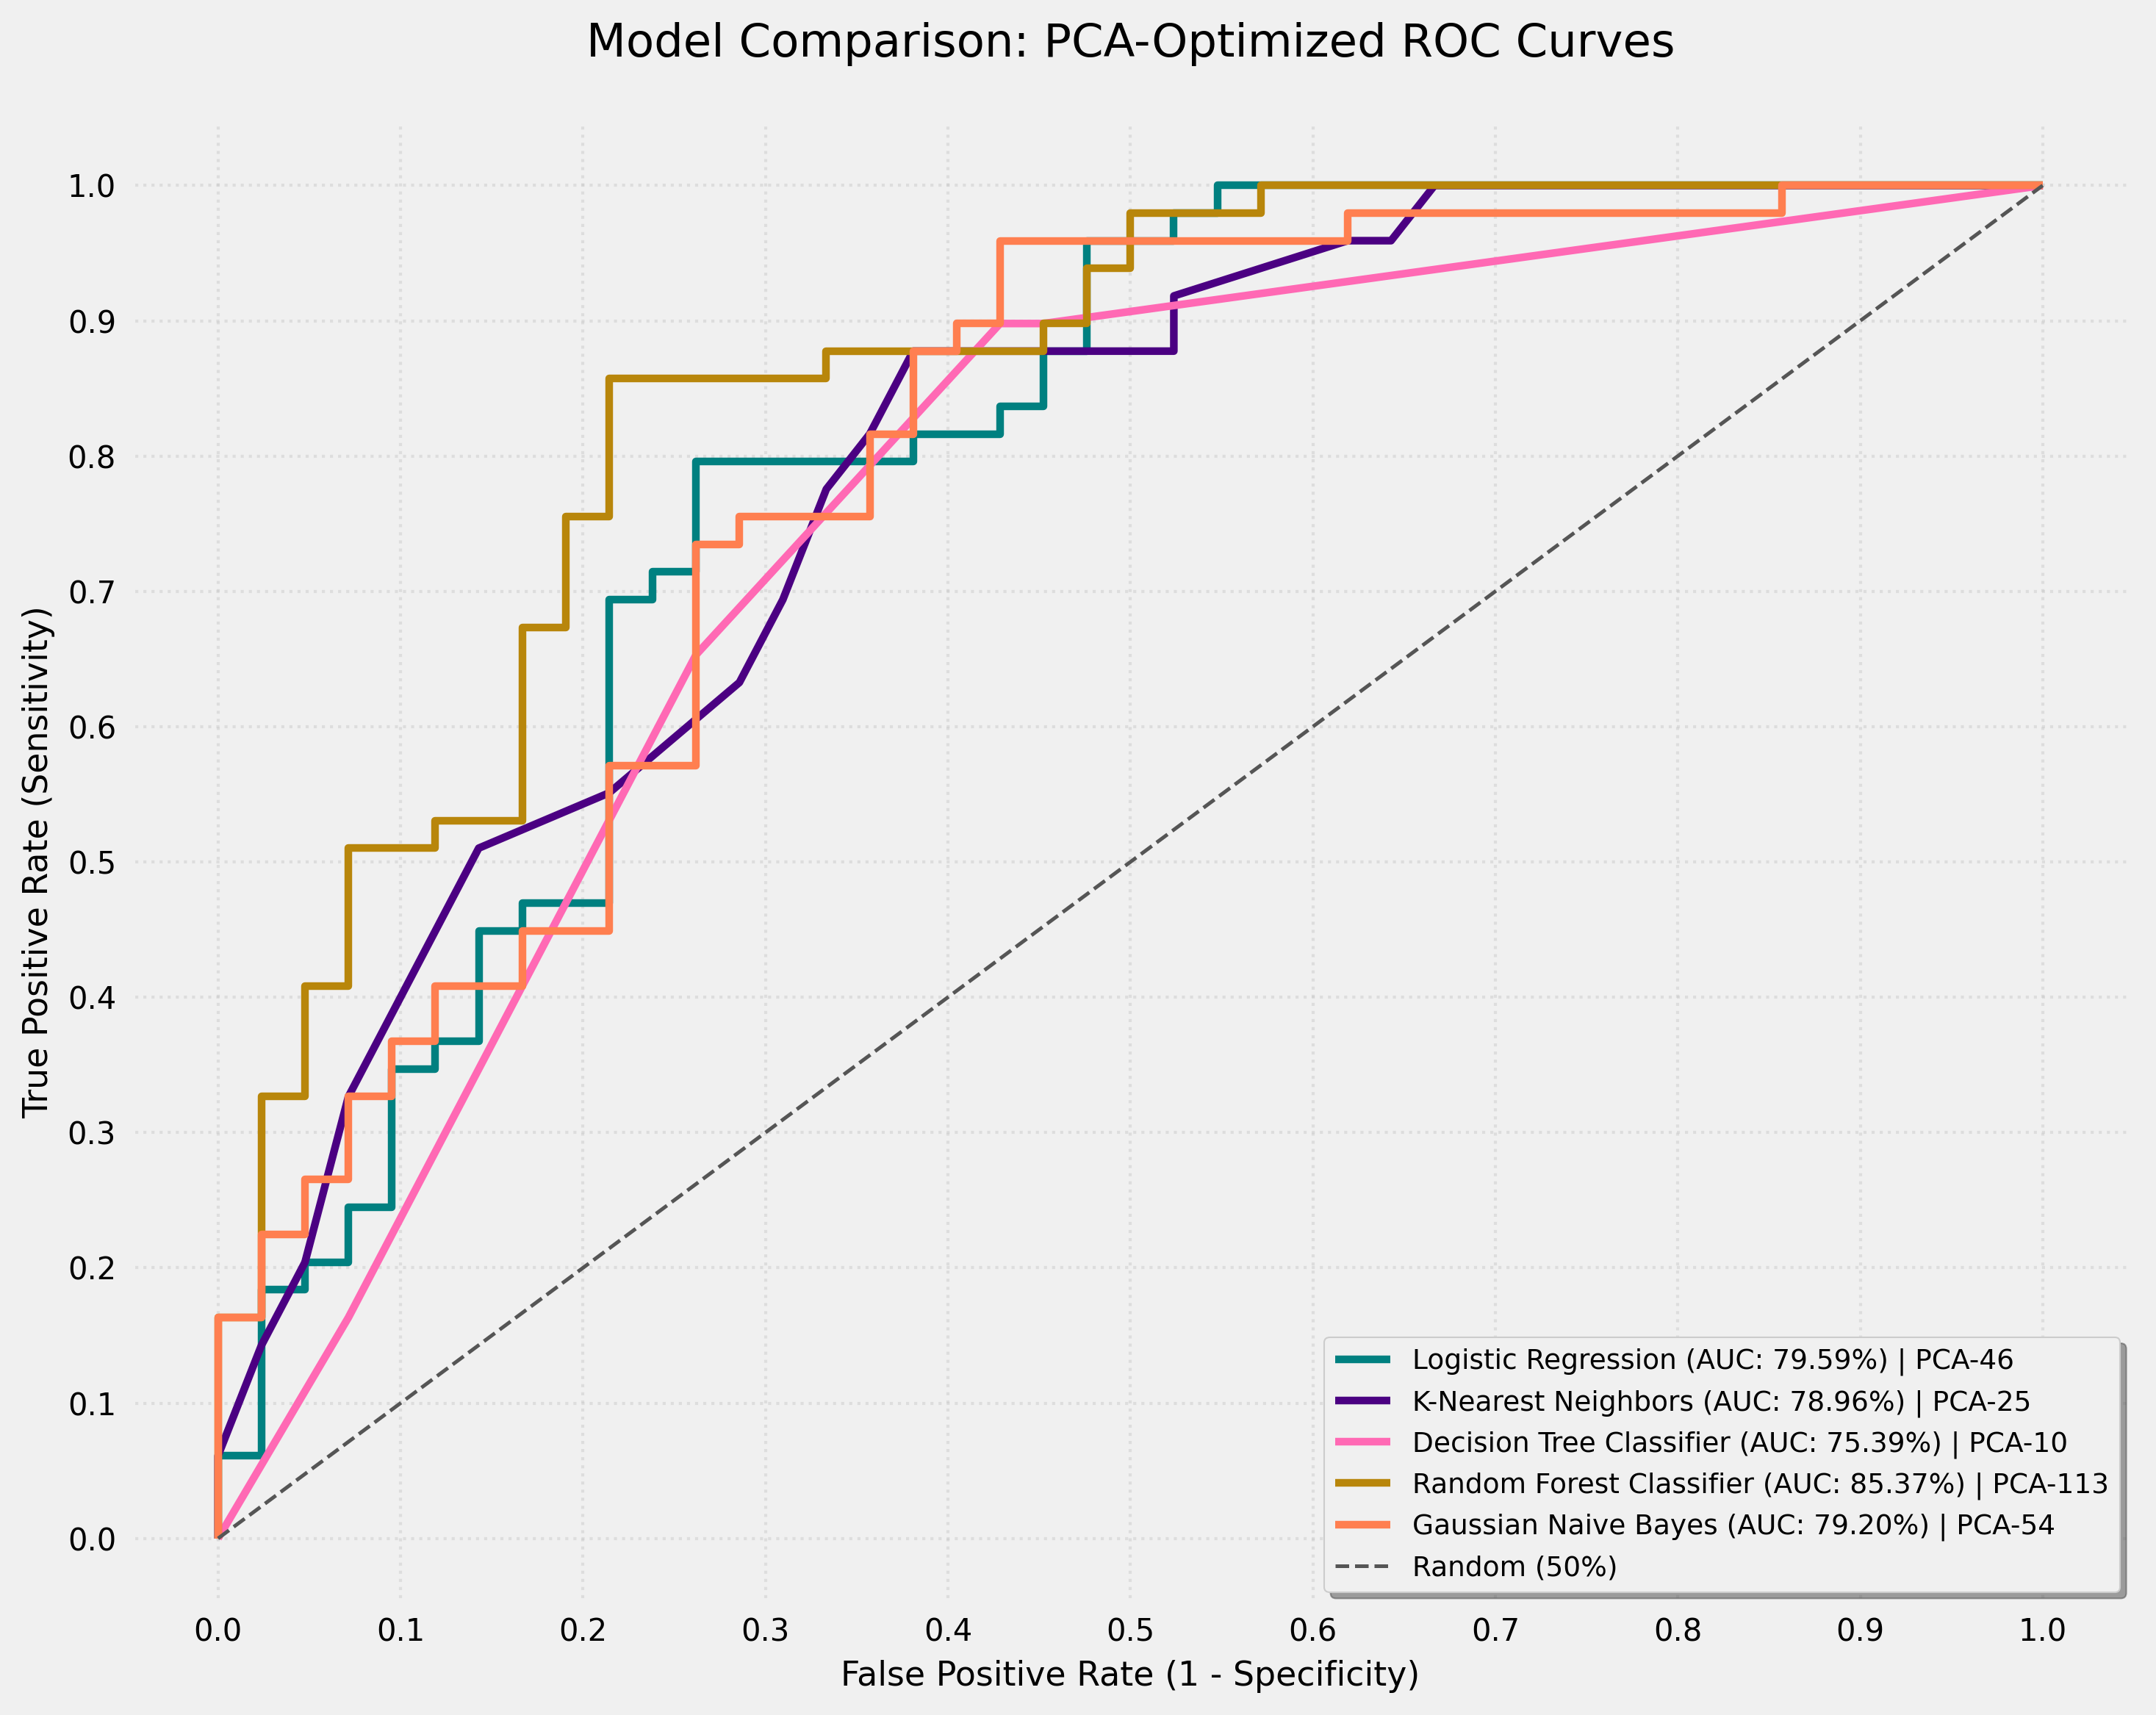

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Initialize the figure once with high DPI for crisp lines
plt.figure(figsize=(10, 8), dpi=300)

for i, pred in enumerate(pca_pred_probs):
    # Calculate Metrics
    fpr, tpr, _ = roc_curve(y_test, pred[:, 1], drop_intermediate=False)
    auc_score = roc_auc_score(y_test, pred[:, 1])
    
    # 2. Create a clean label including Model Name, AUC, and PCA components
    # Using :.2% for percentage formatting
    label_text = f"{model_names[i]} (AUC: {auc_score:.2%}) | PCA-{best_ns[i]}"
    
    # 3. Plot each curve on the same axes
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, label=label_text)

# 4. Plot the random chance baseline (diagonal line)
plt.plot([0, 1], [0, 1], linestyle='--', color='#555555', lw=1.2, label="Random (50%)")

# Formatting the single plot
plt.title("Model Comparison: PCA-Optimized ROC Curves", fontsize=15, pad=20)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)

# Professional grid and axis ticks
plt.xticks([x / 10 for x in range(11)], fontsize=10)
plt.yticks([x / 10 for x in range(11)], fontsize=10)
plt.grid(visible=True, linestyle=':', alpha=0.5)

# 5. Add the legend with a slight shadow for better readability
plt.legend(loc="lower right", fontsize=9, frameon=True, shadow=True)

# Tight layout prevents any text from being cut off
plt.tight_layout()

plt.show()

Cell below computes predictions with probabilities using the best performing overall number of PCA components, computed above and stores them in an array.

For a 50% threshold approach confusion matrix is calculated as below however since ROC curves are provided, one can implement their own threshold favoring either high sensitivity or specificity.

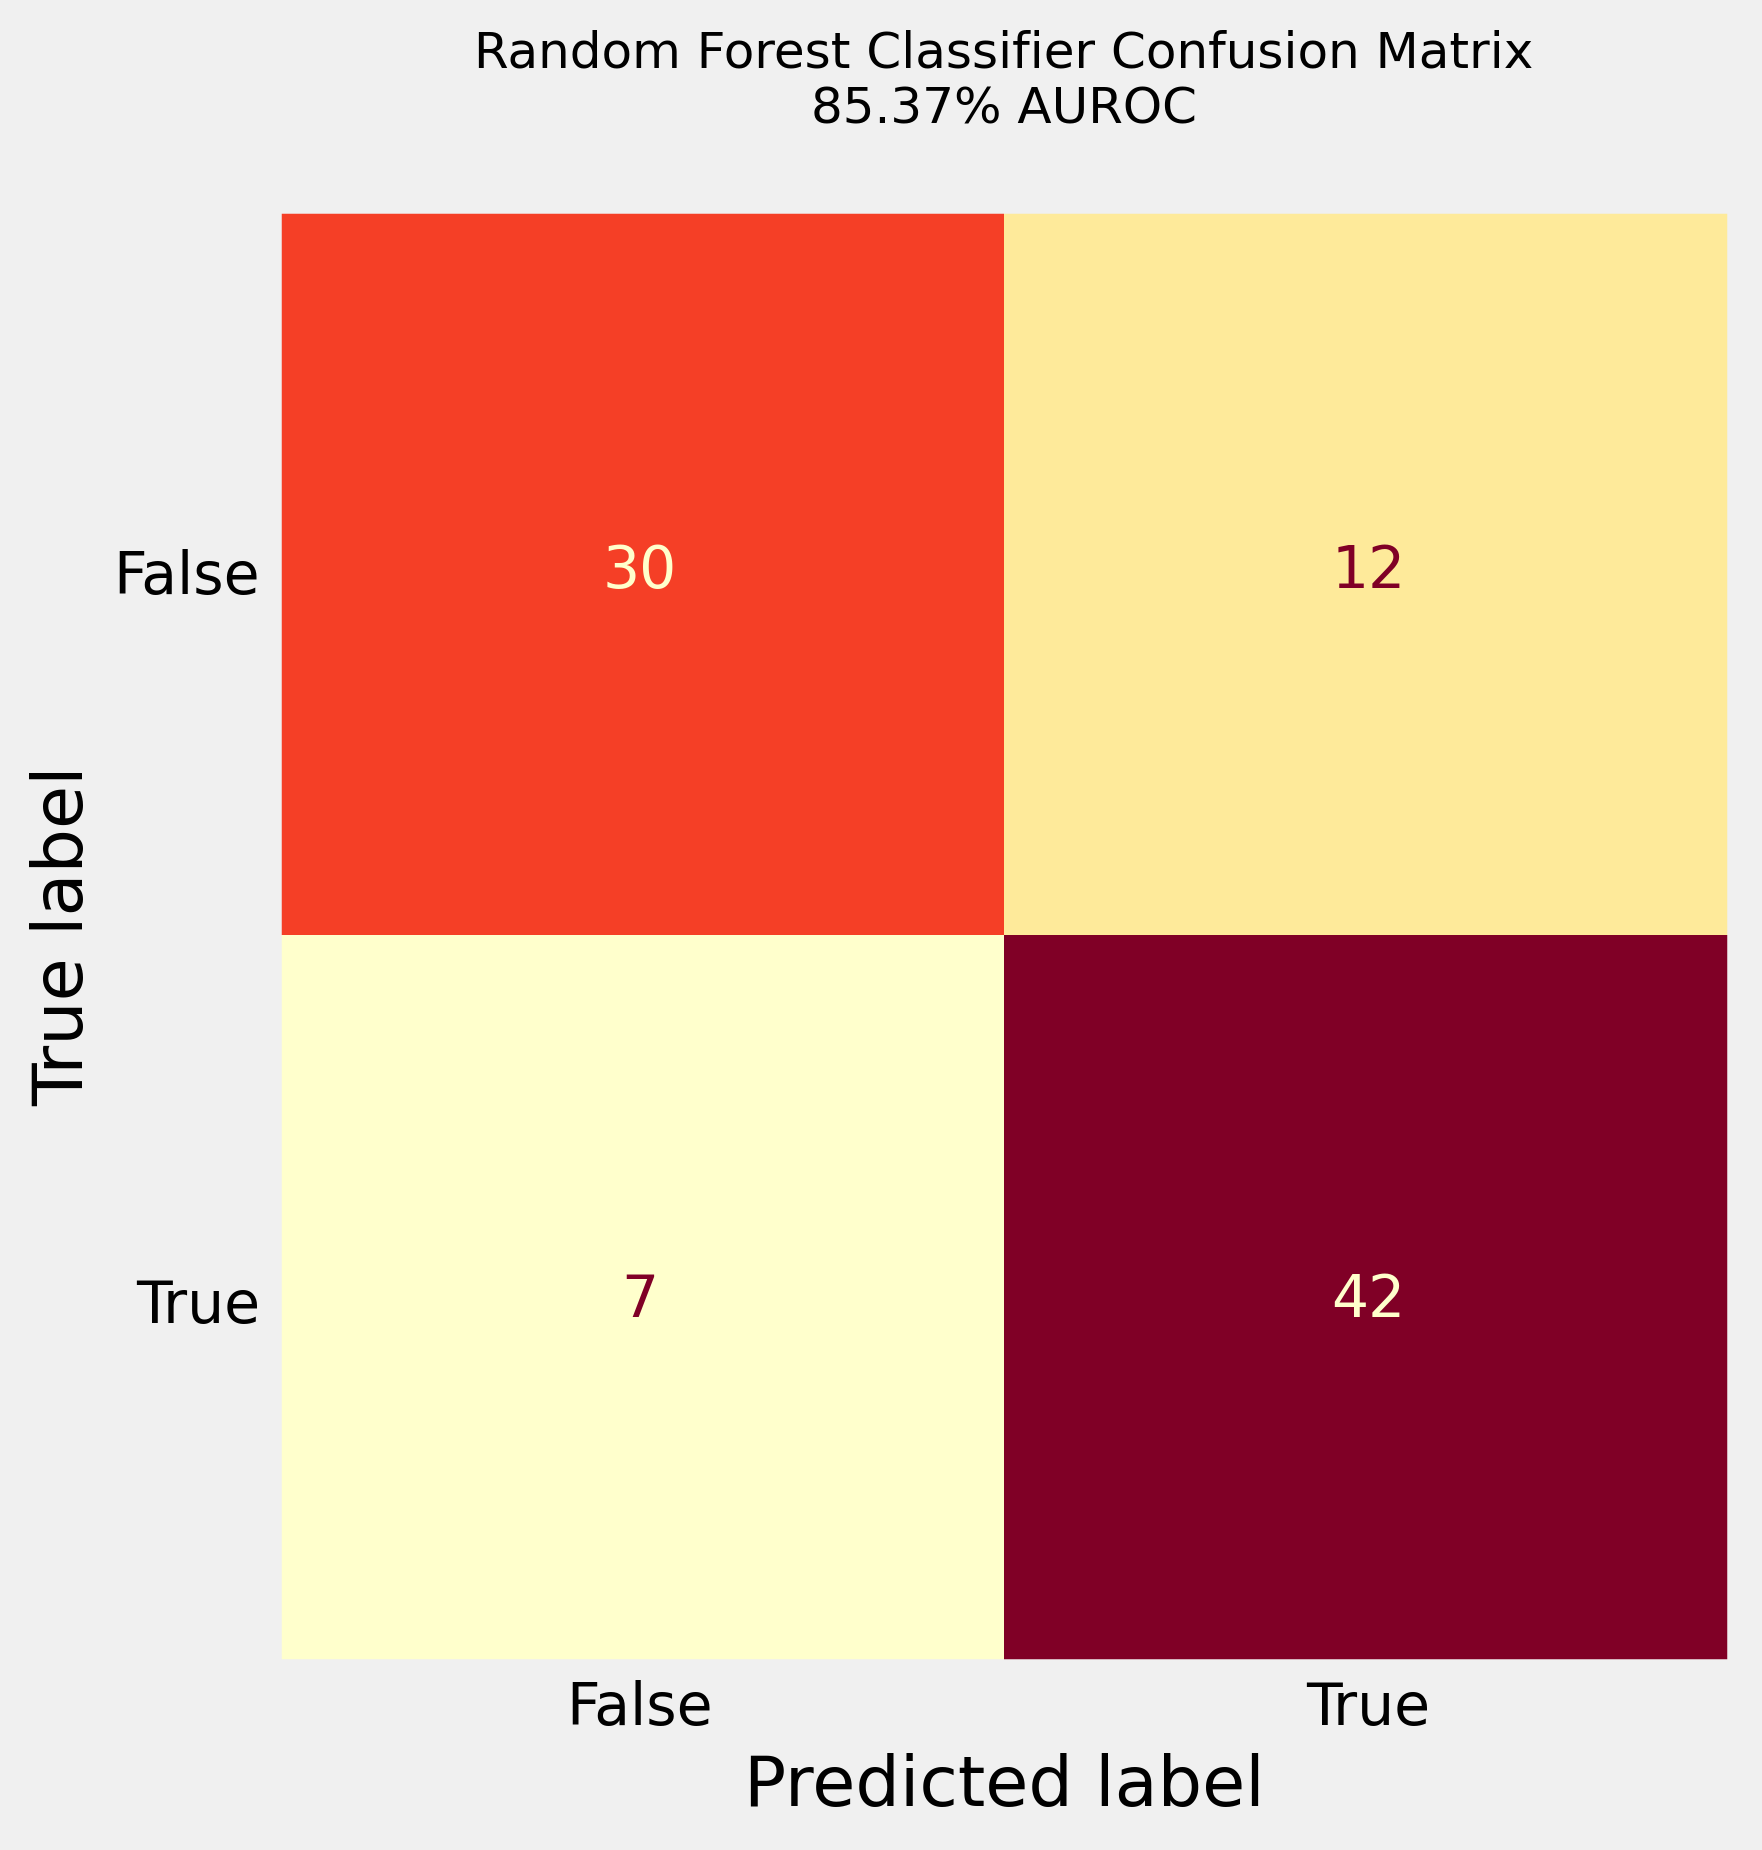

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

y_pred_labels = (ob_best_pred[:, 1] > 0.5).astype(int)
auc_val = roc_auc_score(y_true=y_test, y_score=ob_best_pred[:, 1]) * 100
cm_title = f"{ob_model_name} Confusion Matrix\n{auc_val:.2f}% AUROC"

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_labels,
    cmap=plt.cm.YlOrRd,
    colorbar=False,
    ax=ax
)

ax.set_title(cm_title, fontsize=12, pad=20)
plt.grid(False)
plt.show()